## 0. Configuration, Imports, and Settings

Tested with Python 3.12.11 and Python 3.10.12

- On DigitalOcean, use this kernel: `/usr/bin/python3.12`
- On Orin, use `/usr/bin/python` (3.10)

In [1]:
# Install libraries
%pip install -q "torch>=2.0.0" "tiktoken>=0.5.0" "numpy<2.0.0" "torchinfo==1.8.0" "nltk>=3.8.0" "matplotlib>=3.7.0" "tqdm>=4.65.0" "nltk>=3.8.0"

# Configuration

# Corpus configuration
# verdict (canonical test) | bohemia (one Sherlock story) | sherlock (LARGE!)
TEXT = "sherlock"

# Set to True to upload the model to the Hugging Face Model Hub
# Set to False if pre-trained and fine-tuned models have already been generated
UPLOAD_HUGGING_FACE = False 

# Set to True to use LoRA for fine-tuning
# Set to False for full fine-tuning (slower and requires more memory)
USE_LORA = True


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports and corpus
from pathlib import Path
from src.transformer import PalmoModel

# Constants
VOCAB_PATH = f"data/vocab-{TEXT}.json"
INPUT = Path(f"corpus/{TEXT}.txt")

# Transformer configuration
LEARNING_RATE = 4e-4 # Optimizer learning rate
BATCH_SIZE = 32 # Dataloader batch size
if TEXT == "verdict":
    BATCH_SIZE = 32
    MAX_VOCAB_SIZE = 5000 # number of tokens in the vocabulary
elif TEXT == "bohemia":
    BATCH_SIZE = 32
    MAX_VOCAB_SIZE = 8000 # number of tokens in the vocabulary
elif TEXT == "sherlock":
    BATCH_SIZE = 512 # Batch piu grande
    MAX_VOCAB_SIZE = 15000 # Sherlock piu grande!

# Load the text
text = INPUT.read_text(encoding='utf-8')
words = text.split()

print(text[1550:1800])  # Print characters 1550 through 1800 of the text

 found my regiment, and at once
entered upon my new duties.

The campaign brought honours and promotion to many, but for me it had
nothing but misfortune and disaster. I was removed from my brigade and
attached to the Berkshires, with whom I served a


## 1. Tokenization

Use a Word Boundary Marker

**Problem solved**: The previous implementation used literal spaces, resulting in ~50% of the tokens being dedicated to spaces. The model was therefore exceptionally good at predicting where to place spaces and less able to understand Sherlock Holmes's adventures.

**Solution**: Use the `Ġ` marker (GPT-2 style), which encodes spaces implicitly in word tokens.

In [3]:
# Normalize the corpus to reduce space tokens
import re

original_length = len(text)
original_spaces = text.count(' ')

# 1. Normalize multiple spaces → single space
text = re.sub(r'[ \t]+', ' ', text)

# 2. Normalize multiple newlines (preserve paragraphs)
text = re.sub(r'\n\s*\n\s*\n+', '\n\n', text)

# 3. Remove spaces at the beginning/end of lines
text = re.sub(r'[ \t]+\n', '\n', text)
text = re.sub(r'\n[ \t]+', '\n', text)

# 4. General trim
text = text.strip()

new_length = len(text)
new_spaces = text.count(' ')
reduction = ((original_spaces - new_spaces) / original_spaces * 100) if original_spaces > 0 else 0

print("=== CORPUS NORMALIZATION ===")
print(f"Characters: {original_length:,} → {new_length:,} (reduction {original_length - new_length:,})")
print(f"Spaces: {original_spaces:,} → {new_spaces:,} (reduction {reduction:.1f}%)")
print(f"Corpus normalized in memory (original file untouched)\n")

=== CORPUS NORMALIZATION ===
Characters: 2,631,155 → 2,475,145 (reduction 156,010)
Spaces: 570,933 → 415,305 (reduction 27.3%)
Corpus normalized in memory (original file untouched)



### Tokenizzatore: BPE personalizzato

In [4]:
import os
import json
from src.tokenizer import PalmoTokenizer

if os.path.exists(VOCAB_PATH):
    print(f"Found {VOCAB_PATH}, loading vocabulary and tokens...")
    with open(VOCAB_PATH, "r") as f:
        vocab_data = json.load(f)
    tokenizer = PalmoTokenizer()
    tokenizer.vocab = vocab_data["vocab"]
    tokenizer.reverse_vocab = {int(k): v for k, v in vocab_data["reverse_vocab"].items()}
    tokenizer.merges = [tuple(m) for m in vocab_data["merges"]]
    
    # Load token_ids if available
    if "token_ids" in vocab_data:
        token_ids = vocab_data["token_ids"]
        print(f"Vocabolario caricato: {len(tokenizer.vocab)} token")
        print(f"Token IDs caricati: {len(token_ids):,} token")
    else:
        print(f"Vocabolario caricato: {len(tokenizer.vocab)} token")
        print("Token IDs not found, tokenizing...")
        token_ids = tokenizer.encode(text)
        print(f"Corpus tokenizzato: {len(token_ids):,} token")
        
        # Save token_ids to the file
        vocab_data["token_ids"] = token_ids
        with open(VOCAB_PATH, "w") as f:
            json.dump(vocab_data, f, ensure_ascii=False, indent=2)
        print(f"Token IDs salvati in {VOCAB_PATH}")
else:
    print("Training BPE on the full text...")
    tokenizer = PalmoTokenizer(MAX_VOCAB_SIZE)
    tokenizer.bpe(text)
    print(f"Vocabolario finale: {len(tokenizer.vocab)} token")
    
    # Tokenize the corpus
    print("Tokenizzazione corpus...")
    token_ids = tokenizer.encode(text)
    print(f"Corpus tokenizzato: {len(token_ids):,} token")
    
    # Salva tutto insieme
    vocab_data = {
        "vocab": tokenizer.vocab,
        "reverse_vocab": {str(k): v for k, v in tokenizer.reverse_vocab.items()},
        "merges": tokenizer.merges,
        "token_ids": token_ids
    }
    os.makedirs(os.path.dirname(VOCAB_PATH), exist_ok=True)
    with open(VOCAB_PATH, "w") as f:
        json.dump(vocab_data, f, ensure_ascii=False, indent=2)
    print(f"Vocabulary and tokens saved to {VOCAB_PATH}")

tokens_to_show = list(tokenizer.vocab.keys())[1000:1016]
token_ids_to_show = [tokenizer.vocab[token] for token in tokens_to_show]

print("\nLearned token array: ", tokens_to_show)
print("Token ID array: ", token_ids_to_show)

Found data/vocab-sherlock.json, loading vocabulary and tokens...
Vocabolario caricato: 15000 token
Token IDs caricati: 520,959 token

Learned token array:  ['ter,</w>', 'red</w>', 'pect', 'ly,</w>', 'ained</w>', 'ange</w>', 'aid</w>', 'ay,</w>', 'Ġobs', 'tered</w>', 'Ġlat', 'Ġwell</w>', 'ish', 'Ġlook</w>', 'ched</w>', 'ĠStre']
Token ID array:  [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015]


Bohemia corpus with 8K tokens = about 13s

Sherlock corpus with 15K tokens = 60m 59s

### Statistiche

In [5]:
# Basic corpus analysis with NLTK
import nltk
from collections import Counter

# Basic statistics
num_chars = len(text)
num_tokens = len(token_ids)
vocab_size = len(tokenizer.vocab)

print(f"STATISTICS FOR {TEXT}:")
print(f"  Characters in corpus: {num_chars:,}")
print(f"  Tokens generated: {num_tokens:,}")
print(f"  Vocabulary size: {vocab_size:,}")

# Top 10 most frequent tokens
print(f"\n10 MOST FREQUENT TOKENS:")
token_counts = Counter(token_ids)
most_common = token_counts.most_common(10)
for i, (token_id, count) in enumerate(most_common, 1):
    token_str = tokenizer.decode([token_id])
    token_repr = repr(token_str)[1:-1]  # Remove outer quotes
    percentage = (count / num_tokens) * 100
    print(f"  {i:2d}. '{token_repr} ' (ID {token_id}): {count:7,} ({percentage:.2f}%)")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


STATISTICS FOR sherlock:
  Characters in corpus: 2,475,145
  Tokens generated: 520,959
  Vocabulary size: 15,000

10 MOST FREQUENT TOKENS:
   1. ' the ' (ID 121):  23,448 (4.50%)
   2. ' and ' (ID 139):  11,868 (2.28%)
   3. ' of ' (ID 141):  11,682 (2.24%)
   4. ' to ' (ID 146):  11,072 (2.13%)
   5. ' a ' (ID 151):  10,419 (2.00%)
   6. ' I ' (ID 152):  10,245 (1.97%)
   7. ' that ' (ID 170):   7,085 (1.36%)
   8. ' in ' (ID 172):   7,046 (1.35%)
   9. ' was ' (ID 174):   6,593 (1.27%)
  10. ' his ' (ID 185):   5,110 (0.98%)


First naive and incorrect BPE implementation:

10 MOST FREQUENT TOKENS:
   1. '  ' (ID 2):   3,438 (49.99%)
   2. 'the ' (ID 87):     136 (1.98%)
   3. 'of ' (ID 92):     111 (1.61%)
   4. 'a ' (ID 93):      89 (1.29%)
   5. 'to ' (ID 95):      87 (1.27%)
   6. 'and ' (ID 96):      86 (1.25%)
   7. 'I ' (ID 97):      74 (1.08%)
   8. 'his ' (ID 113):      56 (0.81%)
   9. 'in ' (ID 119):      45 (0.65%)
  10. 'you ' (ID 130):      39 (0.57%)

## 2. Implementing Palmo's Transformer

In [6]:
# Configurazione modello Palmo (pag. 95)
import torch
from torchinfo import summary

config = {
    'vocab_size': MAX_VOCAB_SIZE,
    'embed_dim': 256,
    'n_heads': 8,
    'n_layers': 12,
    'context_length': 256,
    'dropout': 0.1,
}

model = PalmoModel(config)

# Show the model summary
summary(model, input_size=(1, config['context_length']), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
PalmoModel                               [1, 256, 15000]           --
├─Embedding: 1-1                         [1, 256, 256]             3,840,000
├─Embedding: 1-2                         [256, 256]                65,536
├─Dropout: 1-3                           [1, 256, 256]             --
├─ModuleList: 1-4                        --                        --
│    └─TransformerBlock: 2-1             [1, 256, 256]             --
│    │    └─LayerNorm: 3-1               [1, 256, 256]             512
│    │    └─MultiHeadAttention: 3-2      [1, 256, 256]             263,168
│    │    └─Dropout: 3-3                 [1, 256, 256]             --
│    │    └─LayerNorm: 3-4               [1, 256, 256]             512
│    │    └─FeedForward: 3-5             [1, 256, 256]             525,568
│    │    └─Dropout: 3-6                 [1, 256, 256]             --
│    └─TransformerBlock: 2-2             [1, 256, 256]        

In [7]:
# Determine the available device and move the model
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = model.to(device)
print(f"Uso: {device}\n")

Uso: cuda



## 3. Pre-training

In [8]:
from src.pretraining import load_dataset, pretrain_model, save_checkpoint, load_checkpoint

# Check whether a saved "best" checkpoint already exists
checkpoint_path = f"checkpoints/palmo-{TEXT}-best.pt"
if os.path.exists(checkpoint_path):
    print(f"Checkpoint found: {checkpoint_path}, loading model...\n")
    checkpoint_data = load_checkpoint(checkpoint_path, model)
    
    # Estrai la history dal checkpoint (se presente)
    # I checkpoint "best" potrebbero non avere train_losses/val_losses salvati
    # In quel caso, prova a caricare da un checkpoint di epoca o inizializza liste vuote
    if 'train_losses' in checkpoint_data and checkpoint_data['train_losses']:
        history = {
            'train_losses': checkpoint_data['train_losses'], 
            'val_losses': checkpoint_data.get('val_losses', None)
        }
        print(f"History caricato dal checkpoint: {len(history['train_losses'])} epoche")
    else:
        # Se il checkpoint best non ha la history, prova a caricare da pretrained
        pretrained_path = f"checkpoints/palmo-{TEXT}-pretrained.pt"
        if os.path.exists(pretrained_path):
            print(f"Checkpoint best non contiene history, provo {pretrained_path}...")
            pretrained_data = torch.load(pretrained_path, map_location='cpu')
            if 'train_losses' in pretrained_data:
                history = {
                    'train_losses': pretrained_data['train_losses'],
                    'val_losses': pretrained_data.get('val_losses', None)
                }
                print(f"History caricato da pretrained: {len(history['train_losses'])} epoche")
            else:
                print("Nessuna history trovata nei checkpoint, inizializzo vuoto")
                history = {'train_losses': [], 'val_losses': None}
        else:
            print("Nessuna history disponibile nei checkpoint")
            history = {'train_losses': [], 'val_losses': None}
    
else:
    print(f"Nessun checkpoint trovato in {checkpoint_path}, inizia training...")
    
    # Crea il DataLoader per il training (usa token_ids pre-calcolati)
    # load_dataset restituisce (train_loader, val_loader)
    train_loader, val_loader = load_dataset(token_ids, config['context_length'], batch_size=BATCH_SIZE)
    history = pretrain_model(model, train_loader, val_loader=val_loader, epochs=10, lr=LEARNING_RATE, checkpoint_dir="checkpoints", corpus_name=TEXT)

Checkpoint found: checkpoints/palmo-sherlock-best.pt, loading model...

Checkpoint caricato da checkpoints/palmo-sherlock-best.pt
Epoca: 4, Loss: 5.909948666890462
History caricato dal checkpoint: 5 epoche


/home/fsoppelsa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Plot saved to checkpoints/palmo-sherlock-training.png


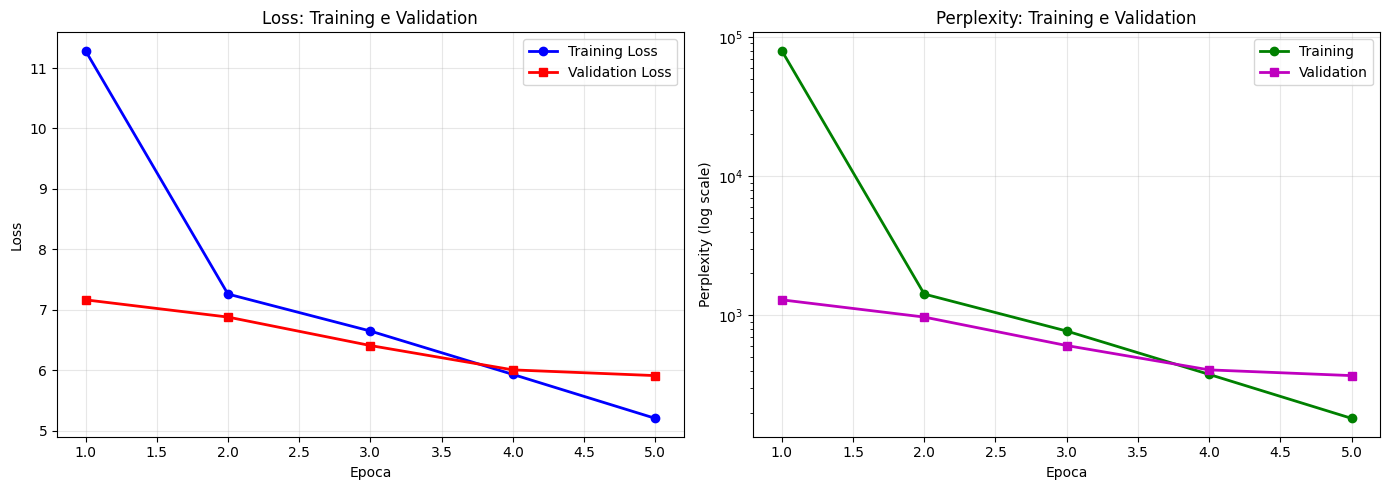


Loss: 11.2873 → 5.2026 (↓53.9%)
Perplexity: 79800.46 → 181.75 (↓99.8%)
Val loss: 5.9099, Perplexity: 368.69


In [9]:
# Plotta grafici di loss e perplexity
import matplotlib.pyplot as plt
import numpy as np

train_losses = history['train_losses']
val_losses = history.get('val_losses')

if not train_losses:
    print("No training data available.")
else:
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
    if val_losses:
        ax1.plot(epochs, val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
    ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss: Training and Validation')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Perplexity con scala logaritmica
    train_perplexities = [np.exp(l) for l in train_losses]
    ax2.plot(epochs, train_perplexities, 'g-o', label='Training', linewidth=2, markersize=6)
    if val_losses:
        val_perplexities = [np.exp(l) for l in val_losses]
        ax2.plot(epochs, val_perplexities, 'm-s', label='Validation', linewidth=2, markersize=6)
    ax2.set(xlabel='Epoch', ylabel='Perplexity (log scale)', title='Perplexity: Training and Validation')
    ax2.set_yscale('log')  # Logarithmic scale for values spanning orders of magnitude
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Salva il grafico come PNG
    plot_path = f"checkpoints/palmo-{TEXT}-training.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Plot saved to {plot_path}")
    
    plt.show()
    
    # Statistiche
    print(f"\nLoss: {train_losses[0]:.4f} → {train_losses[-1]:.4f} (↓{(1-train_losses[-1]/train_losses[0])*100:.1f}%)")
    print(f"Perplexity: {np.exp(train_losses[0]):.2f} → {np.exp(train_losses[-1]):.2f} (↓{(1-np.exp(train_losses[-1])/np.exp(train_losses[0]))*100:.1f}%)")
    if val_losses:
        print(f"Val loss: {val_losses[-1]:.4f}, Perplexity: {np.exp(val_losses[-1]):.2f}")

## 4. Pre-trained Model Quantization

In [10]:
# Quantize the model to reduce size and speed up inference
from src.quantize import quantize_model

# Quantize the model (this can also be done later)
result = quantize_model(
    text_name=TEXT,
    config=config,
    tokenizer=tokenizer,
    history=history,
    test_prompt="The detective said ",
    max_new_tokens=30,
    temperature=0.7
)

MODEL QUANTIZATION
=> Model already quantized; skipping quantization


### Save the models to Hugging Face

They cannot be uploaded to GitHub because they exceed 100 MB.

Use the token from the `hf_token` file.

On macOS:
```
brew install huggingface-cli
pip install huggingface_hub
hf auth login
```


In [11]:
# Import Hugging Face libraries (install only if missing)
import os
from pathlib import Path

try:
    from huggingface_hub import HfApi, login
    print("huggingface_hub available")
except ImportError:
    print("Installing huggingface_hub...")
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--user", "huggingface_hub>=0.23.0"], check=True)
    from huggingface_hub import HfApi, login
    print("huggingface_hub installed")

if UPLOAD_HUGGING_FACE:
    # Disable interactive widgets to avoid rendering errors
    os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

    if Path("hf_token").exists():
        HF_TOKEN = Path("hf_token").read_text().strip()
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Authenticated with token!")
    else:
        print("Token not found in hf_token")
        login()  # Prompt interattivo / funziona?

    # Inizializza HF API
    api = HfApi()

    # Mie credenziali HuggingFace
    REPO_ID = "Fabrizio99/unipa-palmo-nlp"
    print(f"Carico modelli su {REPO_ID}...\n")

    # Carica
    model_files = [
        f"checkpoints/palmo-{TEXT}-best.pt",
        f"checkpoints/palmo-{TEXT}-pretrained.pt",
        f"checkpoints/palmo-{TEXT}-quantized.pt",
    ]

    for model_file in model_files:
        if Path(model_file).exists():
            print(f"Carico {model_file}...")
            api.upload_file(
                path_or_fileobj=model_file,
                path_in_repo=Path(model_file).name,
                repo_id=REPO_ID,
                repo_type="model"
            )
            print(f"=> Caricato {model_file}")
        else:
            print(f"Not found: {model_file}")

    print(f"\n=> Caricato tutto su: https://huggingface.co/{REPO_ID}")

huggingface_hub available


## 5. Fine-Tuning for Instruction Following

First, generate text at different temperatures with the **best** pre-trained model.

In [12]:
# Text-generation test with the pre-trained model (before fine-tuning)
print("=== PROVA GENERAZIONE TESTO SU " + TEXT + " ===\n")

# Load the best model for testing
test_model = PalmoModel(config)
checkpoint_path = f"checkpoints/palmo-{TEXT}-best.pt"
if os.path.exists(checkpoint_path):
    load_checkpoint(checkpoint_path, test_model)
    test_model.eval()
    print(f"Modello caricato da {checkpoint_path}\n")
else:
    test_model = model.eval() # Use the current model, in evaluation mode
    print("Uso modello corrente\n")

# Different test prompts
test_prompts = [
    "The detective said ",
    "Once upon a time ",
    "At Baker Street ",
]

# Test with different temperatures
temperature = [0.5, 0.8, 1.2]

for prompt in test_prompts:
    print(f"Prompt: '{prompt}'")
    
    for temp in temperature:
        # Encode prompt
        encoded = tokenizer.encode(prompt)
        encoded_tensor = torch.tensor([encoded], dtype=torch.long)
        
        # Genera testo
        with torch.no_grad():
            generated = test_model.generate(encoded_tensor, max_new_tokens=50, temperature=temp)
        
        # Decode
        decoded = tokenizer.decode(generated[0].tolist())
        
        print(f"=> Temp {temp}: {decoded}")
    
    print("\n")

=== PROVA GENERAZIONE TESTO SU sherlock ===

Checkpoint caricato da checkpoints/palmo-sherlock-best.pt
Epoca: 4, Loss: 5.909948666890462
Modello caricato da checkpoints/palmo-sherlock-best.pt

Prompt: 'The detective said '
=> Temp 0.5: The detective said he, “I have not quite sure that you are not so much to be able to work upon your own own little little problem which I have been able to get into the house. I have been so great a little time for some time in my own track. I
=> Temp 0.8: The detective said he. “I’ll give you a gentleman Turner Sir Henry Baskerville Hall, but had he as he followed the gleam of swimming he was getting the _Times_ water,” said nothing.” “That is the lights of the young man who was a man who had as I was the kind
=> Temp 1.2: The detective said I. “Burgled. “What, the office. “This is us have you do anything ten morning.” You have some supernaturs?” CHAPTER VII. Harr “Excellent!” I asked Stapleton piquant voices this uncanding and marked one from sailorMMG

### Generating Training Examples with DeepSeek

**Prompt for DeepSeek** (generate ~600 examples and save them in **data/sherlock-tune.json**):

```
Generate 300 instruction-following examples in English for fine-tuning a small language model
pre-trained on the complete Sherlock Holmes corpus by Arthur Conan Doyle.

The examples should focus on Sherlock Holmes-related topics and Victorian era context:
- Questions about Sherlock Holmes characters (Holmes, Watson, Moriarty, Irene Adler, Lestrade, etc.)
- Famous cases and stories (A Study in Scarlet, The Hound of the Baskervilles, etc.)
- Detective work, deduction methods, and forensic techniques
- Victorian London setting, customs, and society
- Literary analysis of the Sherlock Holmes stories
- Mystery and crime-solving scenarios
- Comparisons with other detective fiction
- Historical context of the Victorian era

Format each example as JSON with "instruction" and "output" fields:
{
  "instruction": "the question or prompt about Sherlock Holmes",
  "output": "a clear, accurate answer (2-3 sentences max)"
}

Examples of good instructions:
- "Who is Professor Moriarty?"
- "What is Sherlock Holmes' method of deduction?"
- "Describe 221B Baker Street"
- "What role does Dr. Watson play in the stories?"
- "Explain the significance of The Hound of the Baskervilles"

Return the full array of 300 examples in valid JSON format.
Make sure outputs are factually correct about the Sherlock Holmes stories.
Keep answers concise (under 100 words each).
```

After obtaining the response, save the output to `data/sherlock-tune.json`.

In [13]:
from src.finetune import finetune, load_instruction_data

# Load the instruction dataset
if TEXT == "sherlock":
    instruction_file = "./data/sherlock-tune.json"
elif TEXT == "bohemia":
    instruction_file = "./data/bohemia-tune.json"
instructions = load_instruction_data(instruction_file)
print(f"Loaded {len(instructions)} instruction examples")

# Show a few examples
for i, ex in enumerate(instructions[:3]):
    print(f"\nExample {i+1}:")
    print(f"Instruction: {ex['instruction']}")
    print(f"Answer: {ex['output'][:100]}...")  # First 100 characters

=> Loaded 585 examples from ./data/sherlock-tune.json
Loaded 585 instruction examples

Example 1:
Instruction: Who is Sherlock Holmes?
Answer: Sherlock Holmes is a fictional consulting detective created by Sir Arthur Conan Doyle. He is renowne...

Example 2:
Instruction: Describe Dr. John H. Watson's role.
Answer: Dr. Watson is Holmes's friend, biographer, and assistant. A former army surgeon, he provides the sto...

Example 3:
Instruction: What is 221B Baker Street?
Answer: 221B Baker Street is the London apartment shared by Sherlock Holmes and Dr. Watson. It serves as the...


**Fine-tuning issue: optimizing loss on every input token, including the instruction rather than only the answer, can damage the base model and lead a small model toward loops and nonsensical sentences.**

In [16]:
# Fine-tune the pre-trained model with instructions
import os
from src.pretraining import load_checkpoint

print("=== FINE-TUNING ===\n")

# Higher learning rate to observe improvements
LEARNING_RATE = 5e-6  
MAX_EPOCHS = 5
PATIENCE = 2

tuned_best_path = f"checkpoints/palmo-{TEXT}-tuned-best.pt"
tuned_path = f"checkpoints/palmo-{TEXT}-tuned.pt"
tuned_quantized_path = f"checkpoints/palmo-{TEXT}-tuned-quantized.pt"

if os.path.exists(tuned_best_path) and os.path.exists(tuned_path):
    print(f"Trovati checkpoint fine-tuned esistenti:")
    print(f"  - {tuned_best_path}")
    print(f"  - {tuned_path}")
    if os.path.exists(tuned_quantized_path):
        print(f"  - {tuned_quantized_path}")
    print("\nCarico modello fine-tuned esistente...\n")
    
    # Check whether the checkpoint has a LoRA structure
    checkpoint = torch.load(tuned_best_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    has_lora_keys = any('lora' in key for key in state_dict.keys())
    
    if has_lora_keys:
        print(f"[INFO] Checkpoint contains a LoRA structure; applying LoRA to the model...\n")
        # Load the model and apply LoRA before loading weights
        finetuned_model = PalmoModel(config)
        from src.finetune import replace_linear_with_lora
        finetuned_model = replace_linear_with_lora(finetuned_model, rank=8, alpha=16)
        # Ora carica i pesi LoRA
        finetuned_model.load_state_dict(state_dict, strict=False)
    else:
        print(f"[INFO] Checkpoint standard (no LoRA), carico normalmente...\n")
        # Carica normalmente
        finetuned_model = PalmoModel(config)
        checkpoint_data = load_checkpoint(tuned_best_path, finetuned_model)
    
    # Load history if available
    if 'history' in checkpoint:
        history = checkpoint['history']
        print(f"Training history caricato\n")
    else:
        history = {'train_losses': [], 'val_losses': []}
        print("Training history unavailable\n")
    
else:
    print("No fine-tuned checkpoint found; starting training...\n")
    
    # Load the best pre-trained model
    finetuned_model = PalmoModel(config)
    checkpoint_path = f"checkpoints/palmo-{TEXT}-best.pt"
    if os.path.exists(checkpoint_path):
        load_checkpoint(checkpoint_path, finetuned_model)
        print(f"Modello base caricato da {checkpoint_path}\n")
    
    # Apply LoRA manually if requested (before starting fine-tuning)
    if USE_LORA:
        from src.finetune import replace_linear_with_lora
        from src.transformer import MultiHeadAttention
        
        print("Applico LoRA al modello...")
        finetuned_model = replace_linear_with_lora(finetuned_model, rank=8, alpha=16)
        
        # Visually verify the model structure
        print("\n=== CHECK: LINEAR LAYERS REPLACED WITH LORA? ===\n")
        attention_layers_shown = 0
        for name, module in finetuned_model.named_modules():
            if isinstance(module, MultiHeadAttention) and attention_layers_shown < 2:
                print(f"{name}:")
                print(f"  W_query: {type(module.W_query).__name__}")
                print(f"  W_key: {type(module.W_key).__name__}")
                print(f"  W_value: {type(module.W_value).__name__}")
                attention_layers_shown += 1
    
    # Fine-tuning — NOTE: device is automatically converted to a string
    print(f"Device for fine-tuning: {device}")
    
    finetuned_model, history = finetune(
        model=finetuned_model,
        tokenizer=tokenizer,
        instruction_data=instructions,
        max_epochs=MAX_EPOCHS,  # Increased from 5 for more training
        batch_size=8,
        lr=LEARNING_RATE,
        device=str(device),  # Convert torch.device to a string ('cuda', 'cpu', 'mps')
        use_lora=False,  # Already applied manually above
        save_path=f"checkpoints/palmo-{TEXT}-tuned.pt",
        text_name=TEXT,
        patience=PATIENCE,  # Increased from 1 (more patient)
        min_delta=0.0,
        val_split=0.2
    )
    
    print("\n=> Fine-tuning completato!")
    print(f"=> Best val_loss: {history['best_val_loss']:.4f}")
    print(f"=> Modello salvato in checkpoints/palmo-{TEXT}-tuned.pt")

=== FINE-TUNING ===

Trovati checkpoint fine-tuned esistenti:
  - checkpoints/palmo-sherlock-tuned-best.pt
  - checkpoints/palmo-sherlock-tuned.pt
  - checkpoints/palmo-sherlock-tuned-quantized.pt

Carico modello fine-tuned esistente...

[INFO] Checkpoint standard (no LoRA), carico normalmente...

Checkpoint loaded from checkpoints/palmo-sherlock-tuned-best.pt
Epoca: 0, Loss: 0.0
Training history caricato



### Experimental LoRA (Low-Rank Adaptation)

Manual LoRA following Raschka's *Build a Large Language Model*, Chapter 6.

**How it works**:
- Freezes all original weights (W)
- Adds low-rank matrices A and B to attention layers recursively
- Final output: W(x) + B(A(x)) * scaling
- Typical rank: 8–16 (versus embedding dimension 256)

In [17]:
# LoRA configuration
if USE_LORA:
    print("MODE: LoRA (Low-Rank Adaptation)")
    print("  - Only ~1% of parameters are trainable")
    print("  - Adapter file size: ~2-5 MB")
    print("  - Training time: similar to full fine-tuning")
    print("  - Memory usage: ~10x lower\n")
else:
    print("MODE: Full Fine-tuning")
    print("  - All parameters are trainable")
    print("  - Model file size: ~80 MB")
    print("  - Requires more GPU/CPU memory\n")

MODE: LoRA (Low-Rank Adaptation)
  - Only ~1% of parameters are trainable
  - Adapter file size: ~2-5 MB
  - Training time: similar to full fine-tuning
  - Memory usage: ~10x lower



### Quantization Note

**PyTorch quantization requirements:**
- ✅ CPU x86 con backend `fbgemm` (Intel/AMD)
- ✅ CPU ARM con backend `qnnpack` (mobile/embedded)
- ❌ Not supported on some architectures

**Errore "NoQEngine"?**
- The system has no available quantization backend
- The code handles the error and skips quantization
- The full (unquantized) model still works

In [18]:
# Quantizza il modello fine-tuned per ridurre dimensioni e caricalo su HF

print("=== QUANTIZZAZIONE MODELLO FINE-TUNED ===\n")

tuned_quantized_path = f"checkpoints/palmo-{TEXT}-tuned-quantized.pt"

if os.path.exists(tuned_quantized_path):
    print(f"Trovato modello quantizzato esistente: {tuned_quantized_path}")
    print("Salto quantizzazione\n")
else:
    print("Nessun modello quantizzato trovato, inizio quantizzazione...\n")
    
    # Determina quale modello caricare (LoRA o normale)
    tuned_best_lora_path = f"checkpoints/palmo-{TEXT}-tuned-best-lora.pt"
    tuned_best_path = f"checkpoints/palmo-{TEXT}-tuned-best.pt"
    
    # Controlla se il modello best contiene già struttura LoRA
    needs_merge = False
    if os.path.exists(tuned_best_path):
        checkpoint = torch.load(tuned_best_path, map_location='cpu', weights_only=False)
        state_dict = checkpoint.get('model_state_dict', checkpoint)
        # Controlla se ci sono chiavi LoRA nel state_dict
        has_lora_keys = any('lora' in key for key in state_dict.keys())
        
        if has_lora_keys:
            print(f"[INFO] Il checkpoint {tuned_best_path} contiene struttura LoRA")
            needs_merge = True
    
    if needs_merge or (USE_LORA and os.path.exists(tuned_best_lora_path) and not os.path.exists(tuned_best_path)):
        print("Merge dei pesi LoRA necessario per quantizzazione...\n")
        
        # Per LoRA: carica base model + applica adapter + merge pesi
        from src.lora_utils import load_lora_adapter, merge_lora_weights
        base_checkpoint = f"checkpoints/palmo-{TEXT}-best.pt"
        
        # Determina quale checkpoint LoRA usare
        lora_checkpoint_path = tuned_best_lora_path if os.path.exists(tuned_best_lora_path) else tuned_best_path
        
        print(f"Carico base model: {base_checkpoint}")
        print(f"Carico LoRA adapter: {lora_checkpoint_path}\n")
        
        quant_model = load_lora_adapter(base_checkpoint, lora_checkpoint_path, config)
        
        # Merge LoRA weights into base model per quantizzazione
        print("Merge dei pesi LoRA nel modello base...")
        quant_model = merge_lora_weights(quant_model)
        
        # Salva il modello merged come -tuned-best.pt per la quantizzazione
        temp_merged_path = f"checkpoints/palmo-{TEXT}-tuned-best.pt"
        
        # Carica la history dal checkpoint LoRA se disponibile
        lora_checkpoint = torch.load(lora_checkpoint_path, map_location='cpu', weights_only=False)
        if 'history' in lora_checkpoint:
            history = lora_checkpoint['history']
        
        torch.save({
            'model_state_dict': quant_model.state_dict(),
            'history': history,
            'epoch': lora_checkpoint.get('epoch', 0),
            'loss': lora_checkpoint.get('loss', 0.0)
        }, temp_merged_path)
        print(f"Modello merged salvato in {temp_merged_path}\n")
        
    elif os.path.exists(tuned_best_path):
        print(f"Trovato modello full fine-tuned: {tuned_best_path}")
    else:
        print(f"[ERROR] Nessun modello fine-tuned trovato!")
        print(f"  Cercato: {tuned_best_path}")
        print(f"  Cercato: {tuned_best_lora_path}")
        quant_model = None
    
    # Ora quantizza usando il file merged (o il file normale se non LoRA)
    if os.path.exists(tuned_best_path):
        from src.quantize import quantize_model
        
        # Quantizza il modello fine-tuned con NUOVO template
        tuned_result = quantize_model(
            text_name=f"{TEXT}-tuned",
            config=config,
            tokenizer=tokenizer,
            history=history,
            test_prompt="Question: Who is Sherlock Holmes?\nAnswer: ",  # Nuovo template senza ###
            max_new_tokens=50,
            temperature=0.7
        )
        
        print(f"\n=> Modello fine-tuned quantizzato: {tuned_quantized_path}")
    else:
        print("[ERROR] Non posso quantizzare senza un checkpoint valido")

UPLOAD_HUGGING_FACE = True  # Cambia a True per caricare i modelli fine-tuned su HF
if UPLOAD_HUGGING_FACE:
    print("=== CARICAMENTO MODELLI FINE-TUNED SU HUGGING FACE ===\n")
    api = HfApi()
    REPO_ID = "Fabrizio99/unipa-palmo-nlp"

    all_model_files = [
        f"checkpoints/palmo-{TEXT}-tuned.pt",
        f"checkpoints/palmo-{TEXT}-tuned-best.pt",
        f"checkpoints/palmo-{TEXT}-tuned-best-lora.pt",
        f"checkpoints/palmo-{TEXT}-tuned-quantized.pt",
    ]

    for model_file in all_model_files:
        if Path(model_file).exists():
            print(f"Carico {model_file}...")
            api.upload_file(
                path_or_fileobj=model_file,
                path_in_repo=Path(model_file).name,
                repo_id=REPO_ID,
                repo_type="model"
            )
            print(f"=> Caricato {Path(model_file).name}")
        else:
            print(f"Non trovato: {model_file}")

    print(f"\n=> Tutti i modelli tuned caricati su: https://huggingface.co/{REPO_ID}")

=== FINE-TUNED MODEL QUANTIZATION ===

Existing quantized model found: checkpoints/palmo-sherlock-tuned-quantized.pt
Skipping quantization

=== UPLOADING FINE-TUNED MODELS TO HUGGING FACE ===

Carico checkpoints/palmo-sherlock-tuned.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


=> Caricato palmo-sherlock-tuned.pt
Carico checkpoints/palmo-sherlock-tuned-best.pt...


...

=> Caricato palmo-sherlock-tuned-best.pt
Non trovato: checkpoints/palmo-sherlock-tuned-best-lora.pt
Carico checkpoints/palmo-sherlock-tuned-quantized.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


=> Caricato palmo-sherlock-tuned-quantized.pt

=> Tutti i modelli tuned caricati su: https://huggingface.co/Fabrizio99/unipa-palmo-nlp


In [19]:
# Mostra statistiche LoRA se usato
if USE_LORA and 'finetuned_model' in locals():
    from src.lora_utils import count_lora_parameters
    
    stats = count_lora_parameters(finetuned_model)
    
    print("=== STATISTICHE LORA ===")
    print(f"Parametri totali: {stats['total_params']:,}")
    print(f"Parametri LoRA: {stats['lora_params']:,}")
    print(f"Parametri trainable: {stats['trainable_params']:,}")
    
    # Stima dimensioni file
    full_size_mb = stats['total_params'] * 4 / (1024**2)  # 4 bytes per float32
    lora_size_mb = stats['lora_params'] * 4 / (1024**2)
    
    print(f"\nDimensioni stimate:")
    print(f"  Full model: ~{full_size_mb:.1f} MB")
    print(f"  LoRA adapter: ~{lora_size_mb:.1f} MB")
elif not USE_LORA:
    print("LoRA non usato (full fine-tuning)")
else:
    print("Modello non ancora fine-tuned")

=== STATISTICHE LORA ===
Parametri totali: 13,383,168
Parametri LoRA: 0
Parametri trainable: 13,383,168

Dimensioni stimate:
  Full model: ~51.1 MB
  LoRA adapter: ~0.0 MB


## Perplexity Analysis

### Memory Diagnostics

If the kernel crashes here, it is probably due to insufficient memory. Options:
- Restart the kernel and rerun only the setup cells
- Skip evaluation of some models (comment out entries in `model_paths`)
- Reduce `max_batches` and `max_samples` in perplexity.py

**Note**: On platforms with limited GPU memory (Jetson Orin), evaluation uses the CPU to avoid out-of-memory errors.

**Quantized models**: They may fail on ARM if PyTorch has no quantization backend (`qnnpack`/`fbgemm`).

In [20]:
# Diagnose available memory
import psutil
import torch

# RAM memory
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.1f} GB")
print(f"Available RAM: {ram.available / (1024**3):.1f} GB")
print(f"Used RAM: {ram.percent:.1f}%")

# GPU memory (if available)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        total = torch.cuda.get_device_properties(i).total_memory / (1024**3)
        allocated = torch.cuda.memory_allocated(i) / (1024**3)
        cached = torch.cuda.memory_reserved(i) / (1024**3)
        print(f"\nGPU {i} ({torch.cuda.get_device_name(i)}):")
        print(f"  Total: {total:.1f} GB")
        print(f"  Allocated: {allocated:.1f} GB")
        print(f"  Cached: {cached:.1f} GB")
        print(f"  Free: {total - cached:.1f} GB")
elif torch.backends.mps.is_available():
    print("\nMPS (Apple Silicon): memory shared with the system")

print("\n[WARNING] If RAM < 8 GB or GPU < 4 GB, some evaluations may fail")

Total RAM: 7.4 GB
Available RAM: 2.0 GB
Used RAM: 72.9%

GPU 0 (Orin):
  Total: 7.4 GB
  Allocated: 0.2 GB
  Cached: 0.5 GB
  Free: 6.9 GB

[WARNING] If RAM < 8 GB or GPU < 4 GB, some evaluations may fail


In [21]:
# If memory is limited, add the models you want to skip
SKIP_MODELS = [
    # 'Pre-trained (best)',
    # 'Pre-trained Quantized',
    # 'Fine-tuned (best)',
    # 'Fine-tuned Quantized',
]

print(f"Models to skip: {SKIP_MODELS if SKIP_MODELS else 'None'}")

Models to skip: None


In [26]:
# Calculate perplexity for all models and compare them
import torch
import os
import sys
from io import StringIO
from contextlib import contextmanager
from src.perplexity import evaluate_model_perplexity
import pandas as pd

@contextmanager
def suppress_prints():
    """Temporarily suppress print output."""
    old_stdout = sys.stdout
    sys.stdout = StringIO()
    try:
        yield
    finally:
        sys.stdout = old_stdout

# Force CPU to avoid OOM on Jetson Orin
# Limited GPU memory can cause crashes during evaluation
print("[INFO] Using CPU for perplexity evaluation (avoids GPU OOM)")
eval_device = torch.device('cpu')

model_paths = {
    'Pre-trained (best)': f"checkpoints/palmo-{TEXT}-best.pt",
    'Pre-trained Quantized': f"checkpoints/palmo-{TEXT}-quantized.pt",
    'Fine-tuned (best)': f"checkpoints/palmo-{TEXT}-tuned-best.pt",
    'Fine-tuned Quantized': f"checkpoints/palmo-{TEXT}-tuned-quantized.pt",
}

# Evaluate each model
perplexity_results = {}

for model_name, model_path in model_paths.items():
    # Skip models listed in SKIP_MODELS
    if model_name in SKIP_MODELS:
        print(f"[SKIP] Skipping {model_name} (configured in SKIP_MODELS)")
        continue
        
    if not os.path.exists(model_path):
        print(f"[SKIP] {model_name} not found")
        continue
        
    print(f"Evaluating {model_name}...")
    
    # All models use CPU to avoid OOM
    device_to_use = eval_device
    
    # Determine whether the model is fine-tuned (uses instruction evaluation)
    is_finetuned = 'Fine-tuned' in model_name
    
    # Evaluate using the appropriate method with error handling
    try:
        with suppress_prints():
            result = evaluate_model_perplexity(
                model_name=model_name,
                model_path=model_path,
                model_config=config,
                tokenizer=tokenizer,
                token_ids=token_ids,
                device=device_to_use,
                text_name=TEXT,
                is_finetuned=is_finetuned
            )
        
        if result:
            perplexity_results[model_name] = result
            print(f"  [OK] Perplexity: {result['perplexity']:.2f}")
        else:
            print(f"  [SKIP] No result returned")
            
    except RuntimeError as e:
        error_msg = str(e)
        if "out of memory" in error_msg.lower():
            print(f"  [ERROR] OOM - insufficient memory")
        elif "qengine" in error_msg.lower():
            print(f"  [ERROR] Quantization is not supported on this platform")
        else:
            print(f"  [ERROR] {error_msg[:100]}")
    except Exception as e:
        print(f"  [ERROR] {str(e)[:100]}")
    
    # Free memory between models
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    import gc
    gc.collect()

# Create a DataFrame for table visualization
if perplexity_results:
    df = pd.DataFrame([
        {
            'Model': name,
            'Loss': f"{res['loss']:.4f}",
            'Perplexity': f"{res['perplexity']:.2f}"
        }
        for name, res in perplexity_results.items()
    ])
    
    print("\n=== PERPLEXITY RESULTS ===")
    print(df.to_string(index=False))
    
    # Find the best model
    best_model = min(perplexity_results.items(), key=lambda x: x[1]['perplexity'])
    print(f"\nBest: {best_model[0]} (Perplexity: {best_model[1]['perplexity']:.2f})")
else:
    print("\n[WARNING] No model was evaluated successfully")

[INFO] Using CPU for perplexity evaluation (avoids GPU OOM)
Evaluating Pre-trained (best)...
  [OK] Perplexity: 333.64
Evaluating Pre-trained Quantized...
  [ERROR] Quantization is not supported on this platform
Evaluating Fine-tuned (best)...
  [OK] Perplexity: 1584.35
Evaluating Fine-tuned Quantized...
  [ERROR] Quantization is not supported on this platform

=== PERPLEXITY RESULTS ===
           Model   Loss Perplexity
Pre-trained (best) 5.8101     333.64
 Fine-tuned (best) 7.3679    1584.35

Best: Pre-trained (best) (Perplexity: 333.64)


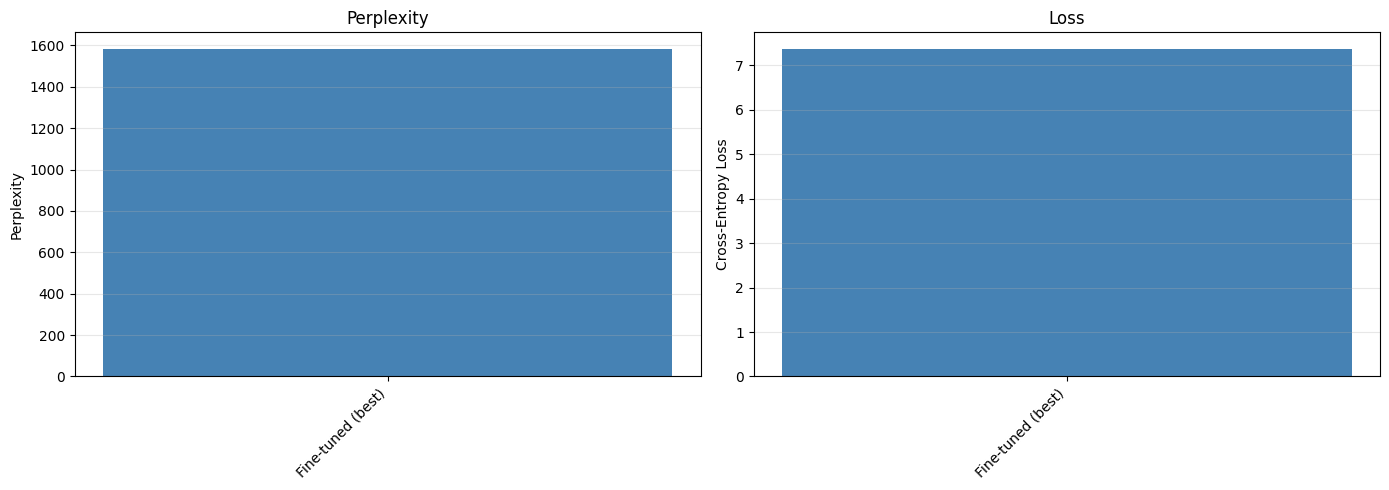

In [23]:
import matplotlib.pyplot as plt

# Extract data for plotting
models = list(perplexity_results.keys())
perplexities = [perplexity_results[m]['perplexity'] for m in models]
losses = [perplexity_results[m]['loss'] for m in models]

# Create bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Perplexity
ax1.bar(range(len(models)), perplexities, color='steelblue')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.set_ylabel('Perplexity')
ax1.set_title('Perplexity')
ax1.grid(axis='y', alpha=0.3)

# Loss
ax2.bar(range(len(models)), losses, color='steelblue')
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_title('Loss')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'checkpoints/palmo-{TEXT}-perplexity-comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conversational assistant

`ask.py` changes `main.TEXT = "bohemia|sherlock"`

In [24]:
# Test the fine-tuned model with different questions and temperatures
print("=== FINE-TUNED MODEL TEST (BEST) ===\n")

# Load the best fine-tuned model — handles both full fine-tuning and LoRA
test_tuned_model = PalmoModel(config)
tuned_best_path = f"checkpoints/palmo-{TEXT}-tuned-best.pt"
tuned_best_lora_path = f"checkpoints/palmo-{TEXT}-tuned-best-lora.pt"

# Check which model type is available and load it correctly
if os.path.exists(tuned_best_path):
    # Check whether the checkpoint has a LoRA structure
    checkpoint = torch.load(tuned_best_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    has_lora_keys = any('lora' in key for key in state_dict.keys())
    
    if has_lora_keys:
        print(f"[INFO] Checkpoint {tuned_best_path} contains LoRA; applying LoRA before loading...\n")
        # Apply LoRA to the empty model before loading weights
        from src.finetune import replace_linear_with_lora
        test_tuned_model = replace_linear_with_lora(test_tuned_model, rank=8, alpha=16)
        test_tuned_model.load_state_dict(state_dict, strict=False)
    else:
        print(f"[INFO] Checkpoint {tuned_best_path} is standard (no LoRA)\n")
        load_checkpoint(tuned_best_path, test_tuned_model)
    
    test_tuned_model = test_tuned_model.to(device)
    test_tuned_model.eval()
    print(f"Fine-tuned model loaded from {tuned_best_path}\n")
    
elif USE_LORA and os.path.exists(tuned_best_lora_path):
    # Fallback: use the separate LoRA checkpoint
    print(f"Separate LoRA model found: {tuned_best_lora_path}")
    print("Loading base model + LoRA adapter and merging...")
    from src.lora_utils import load_lora_adapter, merge_lora_weights
    base_checkpoint = f"checkpoints/palmo-{TEXT}-best.pt"
    test_tuned_model = load_lora_adapter(base_checkpoint, tuned_best_lora_path, config)
    test_tuned_model = merge_lora_weights(test_tuned_model)
    test_tuned_model = test_tuned_model.to(device)
    test_tuned_model.eval()
    print("LoRA weights merged into the model\n")
else:
    print(f"No fine-tuned model found!")
    print(f"  Searched: {tuned_best_path}")
    print(f"  Searched: {tuned_best_lora_path}")
    print("Using the current fine-tuned model\n")
    test_tuned_model = finetuned_model.to(device).eval()

# Simple but meaningful questions for a 12M-parameter model
# Easy enough to answer while still testing instruction-following
if TEXT == "bohemia":
    test_questions = [
        "Who is Irene Adler?",
        "Where does the King come from?",
        "What does Holmes do for a living?"
    ]
elif TEXT == "sherlock":
    test_questions = [
        "Who is Professor Moriarty?",
        "What is Holmes' address?",
        "Who is Dr. Watson?"
    ]

# Temperature 0.8 (lower for more coherent answers)
test_temp = 0.8

print("COMPARISON: PRE-TRAINED vs FINE-TUNED")

# Load the pre-trained model for comparison
pretrained_test = PalmoModel(config)
pretrained_checkpoint = f"checkpoints/palmo-{TEXT}-best.pt"
if os.path.exists(pretrained_checkpoint):
    load_checkpoint(pretrained_checkpoint, pretrained_test)
    pretrained_test = pretrained_test.to(device).eval()
    print("Models loaded: Pre-trained and Fine-tuned\n")

for i, question in enumerate(test_questions, 1):
    print(f"\n[Q{i}] {question}")
    
    encoded = tokenizer.encode(question)
    encoded_tensor = torch.tensor([encoded], dtype=torch.long).to(device)
    input_length = len(encoded)
    
    # Test with the pre-trained model
    with torch.no_grad():
        generated_pt = pretrained_test.generate(
            encoded_tensor,
            max_new_tokens=40,
            temperature=test_temp
        )
    answer_pt = tokenizer.decode(generated_pt[0][input_length:].tolist()).strip()
    
    # Test with the fine-tuned model
    with torch.no_grad():
        generated_ft = test_tuned_model.generate(
            encoded_tensor, 
            max_new_tokens=40,
            temperature=test_temp
        )
    answer_ft = tokenizer.decode(generated_ft[0][input_length:].tolist()).strip()
    
    # Truncate if too long
    if len(answer_pt) > 100:
        answer_pt = answer_pt[:100] + "..."
    if len(answer_ft) > 100:
        answer_ft = answer_ft[:100] + "..."
    
    print(f"Pre-trained:  {answer_pt}")
    print(f"Fine-tuned:   {answer_ft}")
    
print("\nEXPECTATIONS for a 12M model:")
print("  Pre-trained: Continues the story (narrative)")
print("  Fine-tuned: Tries to answer the question directly")
print("  Success = Fine-tuned gives a brief, direct answer")

=== FINE-TUNED MODEL TEST (BEST) ===

[INFO] Checkpoint checkpoints/palmo-sherlock-tuned-best.pt is standard (no LoRA)

Checkpoint loaded from checkpoints/palmo-sherlock-tuned-best.pt
Epoch: 0, Loss: 0.0
Fine-tuned model loaded from checkpoints/palmo-sherlock-tuned-best.pt

COMPARISON: PRE-TRAINED vs FINE-TUNED
Checkpoint loaded from checkpoints/palmo-sherlock-best.pt
Epoch: 4, Loss: 5.909948666890462
Models loaded: Pre-trained and Fine-tuned


[Q1] Who is Professor Moriarty?
Pre-trained:  You will not make of a morery. I shall conceal an emptyts of the matter of Mr. Holmes, I think that ...
Fine-tuned:   Where is the other. You see the weird face of the look?” “Yes, sir.” “He is silent feasable,” said S...

[Q2] What is Holmes' address?
Pre-trained:  You may be a very pretty greatest interest to have been a few of some attentions of the letter which...
Fine-tuned:   You remember how read. “Very does are you see, and awer of the adventure. Why, they call it is to wa...

[Q3] Who is Dr.